In [1]:
pip install pandas nltk textblob matplotlib wordcloud

In [2]:
import pandas as pd

df = pd.read_csv("product_feedback.csv")

print(df.head())
print(df.shape)

                                            Feedback
0  The product quality is excellent and worth the...
1  Very poor packaging and the item arrived damaged.
2            Good quality but the delivery was late.
3            The product is amazing and easy to use.
4           I am disappointed with the battery life.
(50, 1)


In [4]:
import nltk
import string

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    tokens = word_tokenize(text)

    words = []

    for word in tokens:
        if word not in stop_words and word not in string.punctuation:
            words.append(word)

    return " ".join(words)

df["Cleaned_Feedback"] = df["Feedback"].apply(preprocess)

print(df.head())

                                            Feedback  \
0  The product quality is excellent and worth the...   
1  Very poor packaging and the item arrived damaged.   
2            Good quality but the delivery was late.   
3            The product is amazing and easy to use.   
4           I am disappointed with the battery life.   

                        Cleaned_Feedback  
0  product quality excellent worth price  
1    poor packaging item arrived damaged  
2             good quality delivery late  
3               product amazing easy use  
4              disappointed battery life  


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [5]:
from textblob import TextBlob

def sentiment(text):
    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Feedback"].apply(sentiment)

print(df.head())

                                            Feedback  \
0  The product quality is excellent and worth the...   
1  Very poor packaging and the item arrived damaged.   
2            Good quality but the delivery was late.   
3            The product is amazing and easy to use.   
4           I am disappointed with the battery life.   

                        Cleaned_Feedback Sentiment  
0  product quality excellent worth price  Positive  
1    poor packaging item arrived damaged  Negative  
2             good quality delivery late  Positive  
3               product amazing easy use  Positive  
4              disappointed battery life  Negative  


In [6]:
print(df["Sentiment"].value_counts())

Sentiment
Positive    29
Neutral     12
Negative     9
Name: count, dtype: int64


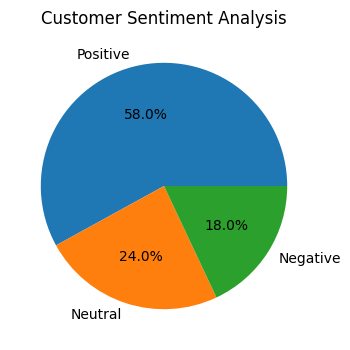

In [8]:
import matplotlib.pyplot as plt

counts = df["Sentiment"].value_counts()

plt.figure(figsize=(4,4))
plt.pie(counts,
        labels=counts.index,
        autopct='%1.1f%%')

plt.title("Customer Sentiment Analysis")
plt.show()

In [9]:
from collections import Counter

negative = df[df["Sentiment"]=="Negative"]

text = " ".join(negative["Cleaned_Feedback"])

words = text.split()

common = Counter(words).most_common(15)

print(common)

[('product', 3), ('poor', 2), ('arrived', 2), ('difficult', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('disappointed', 1), ('battery', 1), ('life', 1), ('instructions', 1), ('confusing', 1), ('customer', 1), ('support', 1), ('quality', 1)]


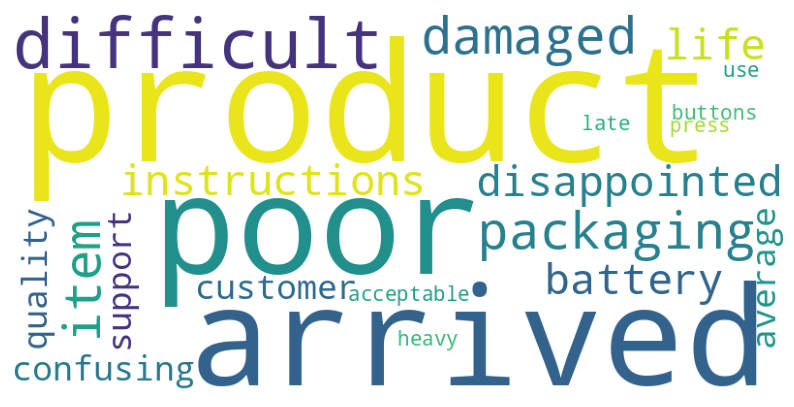

In [11]:
from wordcloud import WordCloud

text = " ".join(negative["Cleaned_Feedback"])

wc = WordCloud(width=800,
               height=400,
               background_color="white").generate(text)

plt.figure(figsize=(10,6))
plt.imshow(wc)
plt.axis("off")
plt.show()

In [12]:
print("Total Feedback:", len(df))

print("\nSentiment Distribution")
print(df["Sentiment"].value_counts())

negative = df[df["Sentiment"]=="Negative"]
keywords = ["battery","price","packaging","quality","delivery","support"]

for word in keywords:
    count = negative["Cleaned_Feedback"].str.contains(word).sum()
    print(word,":",count)

Total Feedback: 50

Sentiment Distribution
Sentiment
Positive    29
Neutral     12
Negative     9
Name: count, dtype: int64
battery : 1
price : 0
packaging : 1
quality : 1
delivery : 0
support : 1


In [13]:
df.to_csv("Product_Feedback_Analysis_Output.csv", index=False)

print("File Saved Successfully")

File Saved Successfully
